# Finalized Figures

Publication- and presentation-ready figures. Each figure is built up in
stages for slide animation.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats as sp_stats

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

COLORS = {"normal": "white", "vse": "black"}
LABELS = {"normal": "Baseline", "vse": "Enhanced"}
REGION_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery", "IVS": "Interventricular Septum", "Air": "Air"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

LEGEND_HANDLES = [
    Patch(facecolor="white", edgecolor="black", linewidth=1.2, label=LABELS["normal"]),
    Patch(facecolor="black", edgecolor="black", linewidth=1.2, label=LABELS["vse"]),
]

data = pd.read_csv(CSV_PATH)
data["snr"] = data["mean"] / data["std"]

SNR_OUTLIER_THRESHOLD = 100
data = data[data["snr"] <= SNR_OUTLIER_THRESHOLD].reset_index(drop=True)

print(f"{len(data)} rows  |  {data['patient'].nunique()} patients")

2354 rows  |  15 patients


In [2]:
regions = sorted(data["region"].unique())
cnr_regions = ["Ao", "PA"]

# SNR
snr_avg = (
    data.groupby(["patient", "region", "reconstruction"])["snr"]
    .mean().reset_index().rename(columns={"snr": "snr_mean"})
)

# CNR_myo
vessels = data[data["region"].isin(cnr_regions)].copy()
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "ivs_mean", "std": "ivs_std"})
cnr_myo_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_myo_data["cnr"] = (cnr_myo_data["mean"] - cnr_myo_data["ivs_mean"]) / cnr_myo_data["ivs_std"]

cnr_myo_avg = (
    cnr_myo_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_myo_pivot = cnr_myo_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_myo_pivot["vse_minus_normal"] = cnr_myo_pivot["vse"] - cnr_myo_pivot["normal"]
snr_pivot = snr_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="snr_mean")

# Time-averaged mean SI
si_avg = (
    data.groupby(["patient", "region", "reconstruction"])["mean"]
    .mean().reset_index().rename(columns={"mean": "si_mean"})
)
si_pivot = si_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="si_mean")
si_pivot["vse_minus_normal"] = si_pivot["vse"] - si_pivot["normal"]

# Stats
def _paired_wilcoxon(pivot_df, region):
    pdf = pivot_df.reset_index()
    sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
    _, p = sp_stats.wilcoxon(sub["vse"].values - sub["normal"].values)
    if p < 0.001: sig = "***"
    elif p < 0.01: sig = "**"
    elif p < 0.05: sig = "*"
    else: sig = "ns"
    return p, sig

sig_cache = {}
for region in cnr_regions:
    sig_cache[("CNR_myo", region)] = _paired_wilcoxon(cnr_myo_pivot, region)
    sig_cache[("SNR", region)] = _paired_wilcoxon(snr_pivot, region)

for k, (p, s) in sig_cache.items():
    print(f"{k[0]:>8s} {k[1]}: p={p:.4f} ({s})")

 CNR_myo Ao: p=0.0003 (***)
     SNR Ao: p=0.4543 (ns)
 CNR_myo PA: p=0.0004 (***)
     SNR PA: p=0.0580 (ns)


## Figure 1: CNR$_{myo}$ — Baseline vs Enhanced

Four build-up stages for slide animation:
1. Empty axes (labels, grid, no data)
2. Baseline only
3. Baseline + Enhanced
4. Full figure with significance brackets

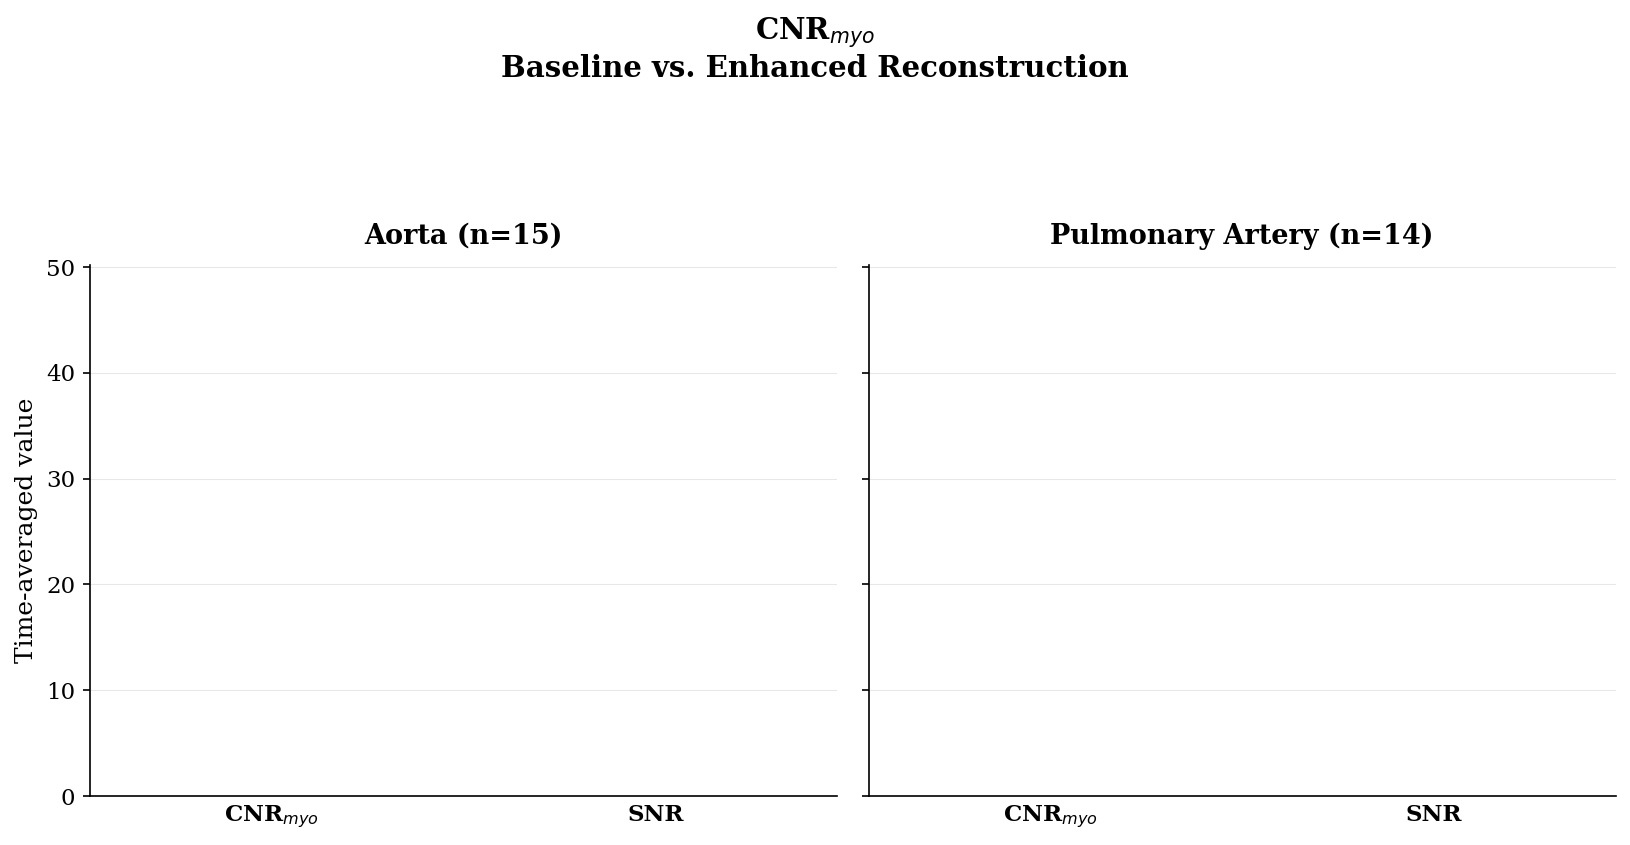

Saved: fig1_cnr_myo_empty.png


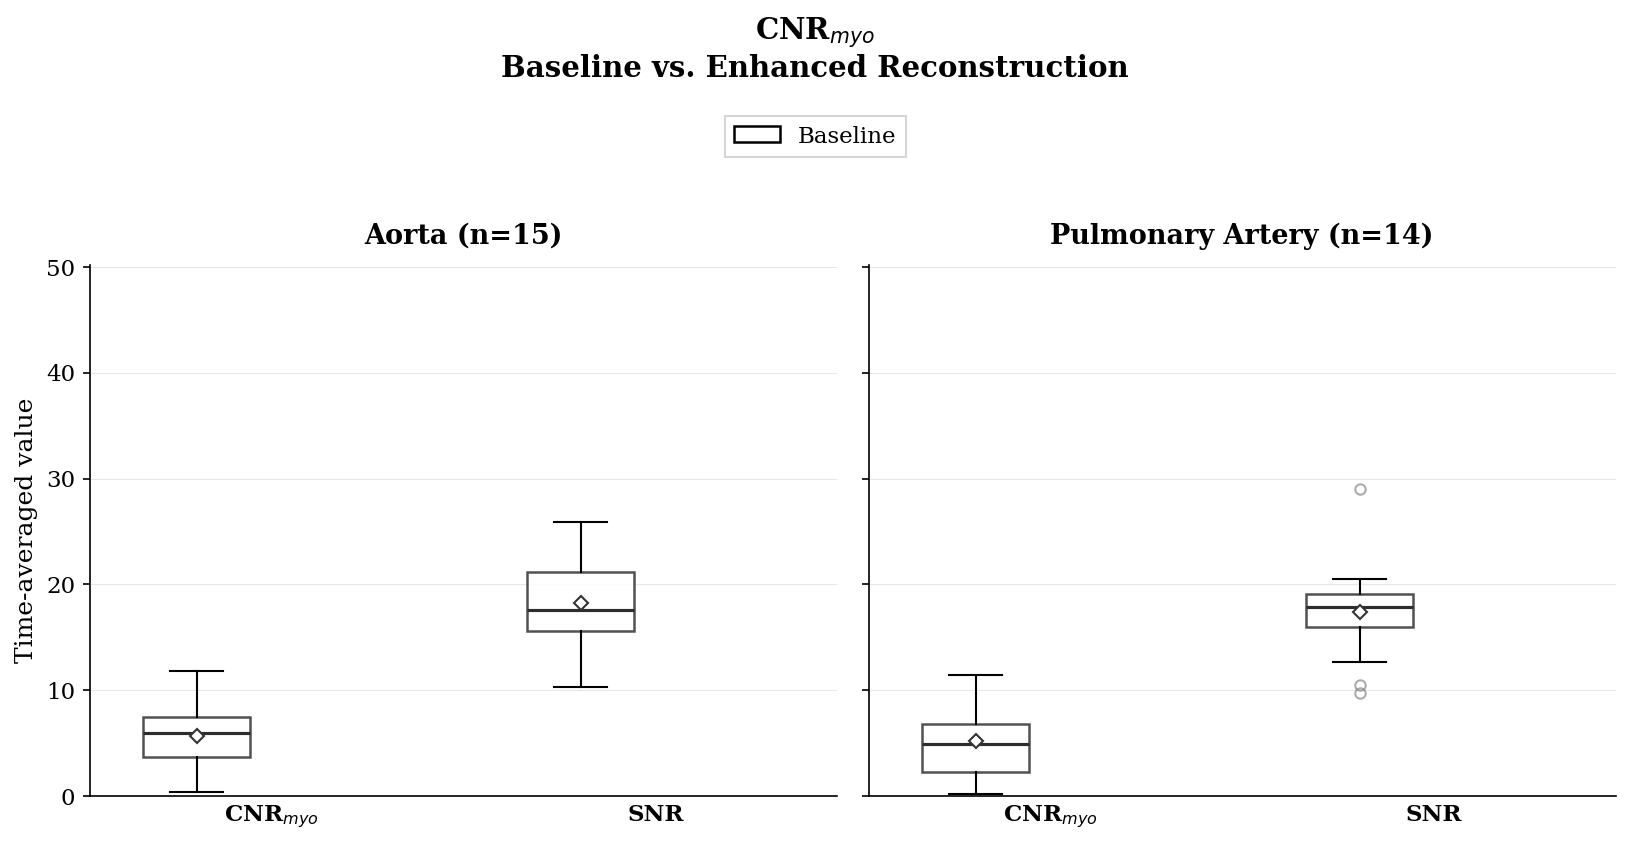

Saved: fig1_cnr_myo_baseline.png


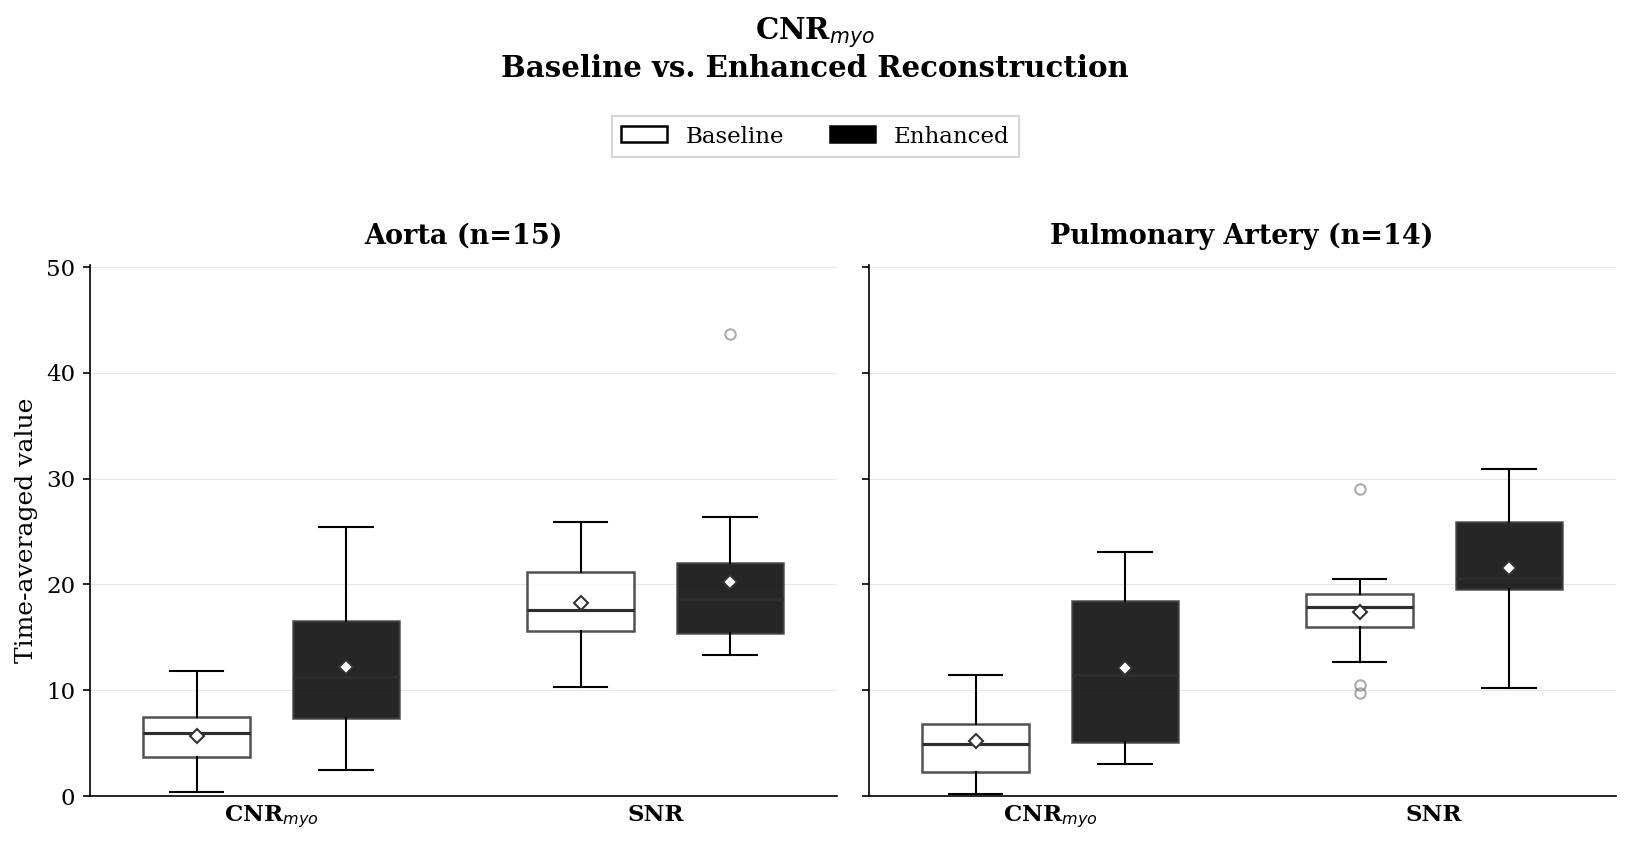

Saved: fig1_cnr_myo_both.png


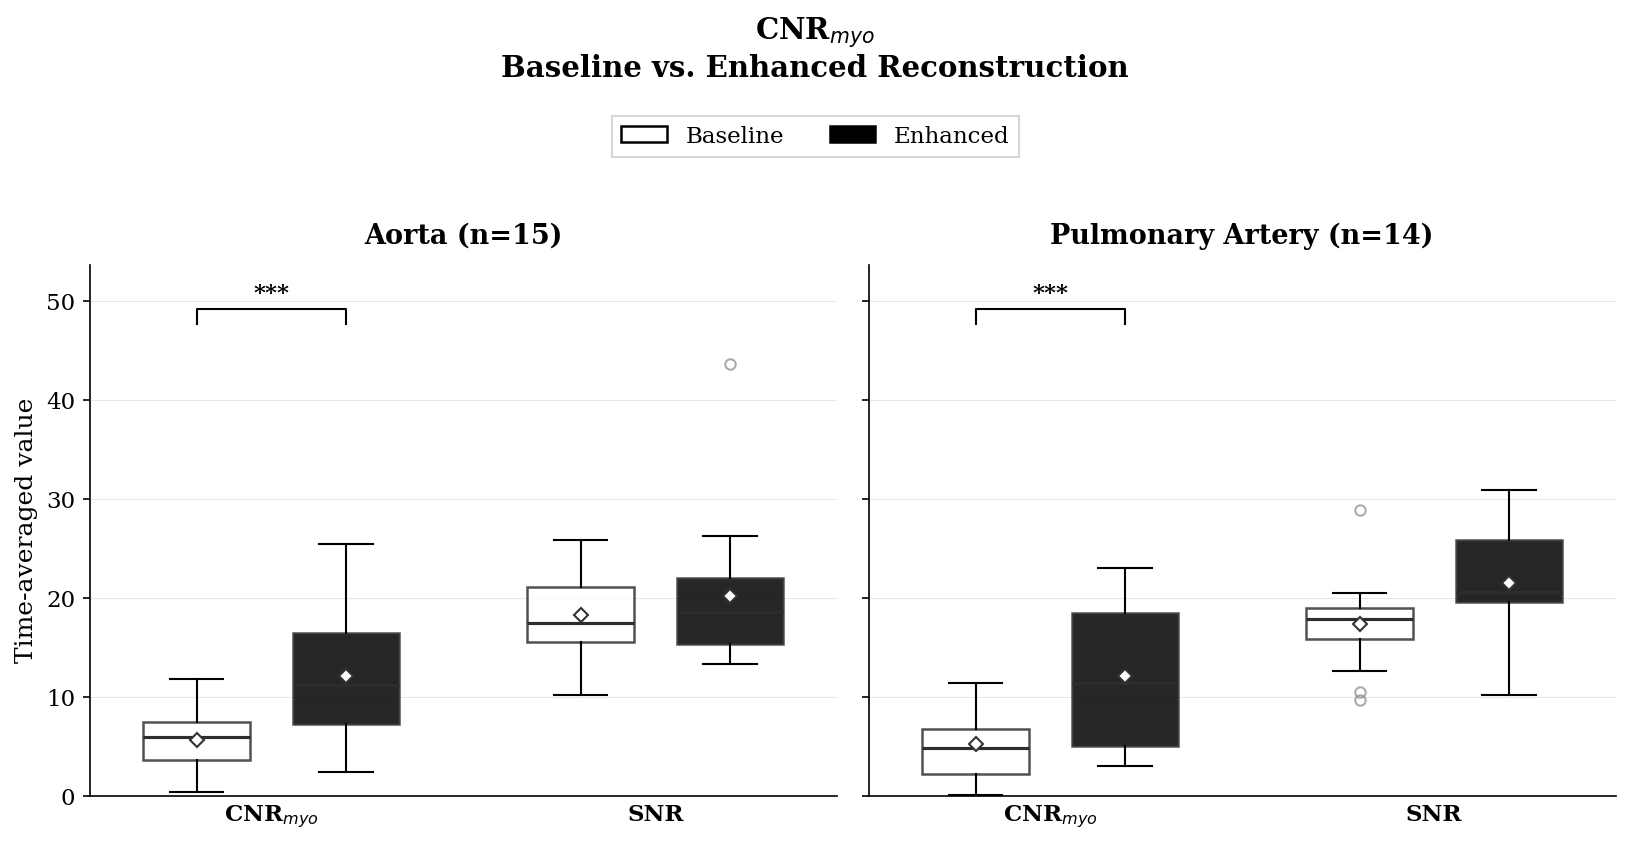

Saved: fig1_cnr_myo_full.png


In [3]:
def _get_nv(df, region, col):
    sub = df[df["region"] == region]
    return (sub[sub["reconstruction"] == "normal"][col],
            sub[sub["reconstruction"] == "vse"][col])

def _annotate_sig(ax, sig, x0, x1):
    if sig == "ns":
        return
    ylim = ax.get_ylim()
    y = ylim[1] - (ylim[1] - ylim[0]) * 0.02
    h = (ylim[1] - ylim[0]) * 0.03
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color="black", linewidth=1.0)
    ax.text((x0 + x1) / 2, y + h * 0.3, sig, ha="center", va="bottom",
            fontsize=11, fontweight="bold")
    ax.set_ylim(ylim[0], y + h * 3)

# Precompute consistent y-limit across all data
all_vals = []
for region in cnr_regions:
    cn, cv = _get_nv(cnr_myo_avg, region, "cnr_mean")
    sn, sv = _get_nv(snr_avg, region, "snr_mean")
    all_vals.extend([cn, cv, sn, sv])
global_max = max(v.max() for v in all_vals)
YLIM = (0, global_max * 1.15)

STAGES = [
    ("empty",    False, False, False),
    ("baseline", True,  False, False),
    ("both",     True,  True,  False),
    ("full",     True,  True,  True),
]

for stage_name, show_baseline, show_enhanced, show_sig in STAGES:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5),
                             sharey=True)

    for ax, region in zip(axes, cnr_regions):
        cnr_n, cnr_v = _get_nv(cnr_myo_avg, region, "cnr_mean")
        snr_n, snr_v = _get_nv(snr_avg, region, "snr_mean")

        box_data = []
        box_positions = []
        box_colors = []

        if show_baseline:
            box_data.extend([cnr_n, snr_n])
            box_positions.extend([0, 1.8])
            box_colors.extend([COLORS["normal"], COLORS["normal"]])

        if show_enhanced:
            box_data.extend([cnr_v, snr_v])
            box_positions.extend([0.7, 2.5])
            box_colors.extend([COLORS["vse"], COLORS["vse"]])

        if box_data:
            bp = ax.boxplot(box_data, positions=box_positions, widths=0.5, **BOXPLOT_KW)
            color_boxes(bp, box_colors)

        ax.set_xlim(-0.5, 3.0)
        ax.set_xticks([0.35, 2.15])
        ax.set_xticklabels(["CNR$_{myo}$", "SNR"], fontweight="bold")
        n_region = len(cnr_n)
        ax.set_title(f"{REGION_LABELS[region]} (n={n_region})", fontweight="bold", pad=10)
        ax.tick_params(axis="x", length=0)
        ax.set_ylim(YLIM)

        if show_sig:
            _, sig_cnr = sig_cache[("CNR_myo", region)]
            _annotate_sig(ax, sig_cnr, x0=0, x1=0.7)
            _, sig_snr = sig_cache[("SNR", region)]
            _annotate_sig(ax, sig_snr, x0=1.8, x1=2.5)

    axes[0].set_ylabel("Time-averaged value")

    legend_handles = []
    if show_baseline:
        legend_handles.append(LEGEND_HANDLES[0])
    if show_enhanced:
        legend_handles.append(LEGEND_HANDLES[1])
    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center", ncol=2,
                   frameon=True, fancybox=False, edgecolor="#ccc",
                   fontsize=11, bbox_to_anchor=(0.5, 1.0))

    fig.suptitle("CNR$_{myo}$\nBaseline vs. Enhanced Reconstruction",
                 fontsize=14, fontweight="bold", y=1.12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig1_cnr_myo_{stage_name}.png",
                bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: fig1_cnr_myo_{stage_name}.png")

## Figure 2: Per-Patient CNR$_{myo}$ — Baseline → Enhanced

Paired slope graph. Each line connects one patient's time-averaged CNR under
Baseline (left) to Enhanced (right). Green = improved; red = decreased.

Build-up stages:
1. Baseline points only
2. Full figure with lines to Enhanced points

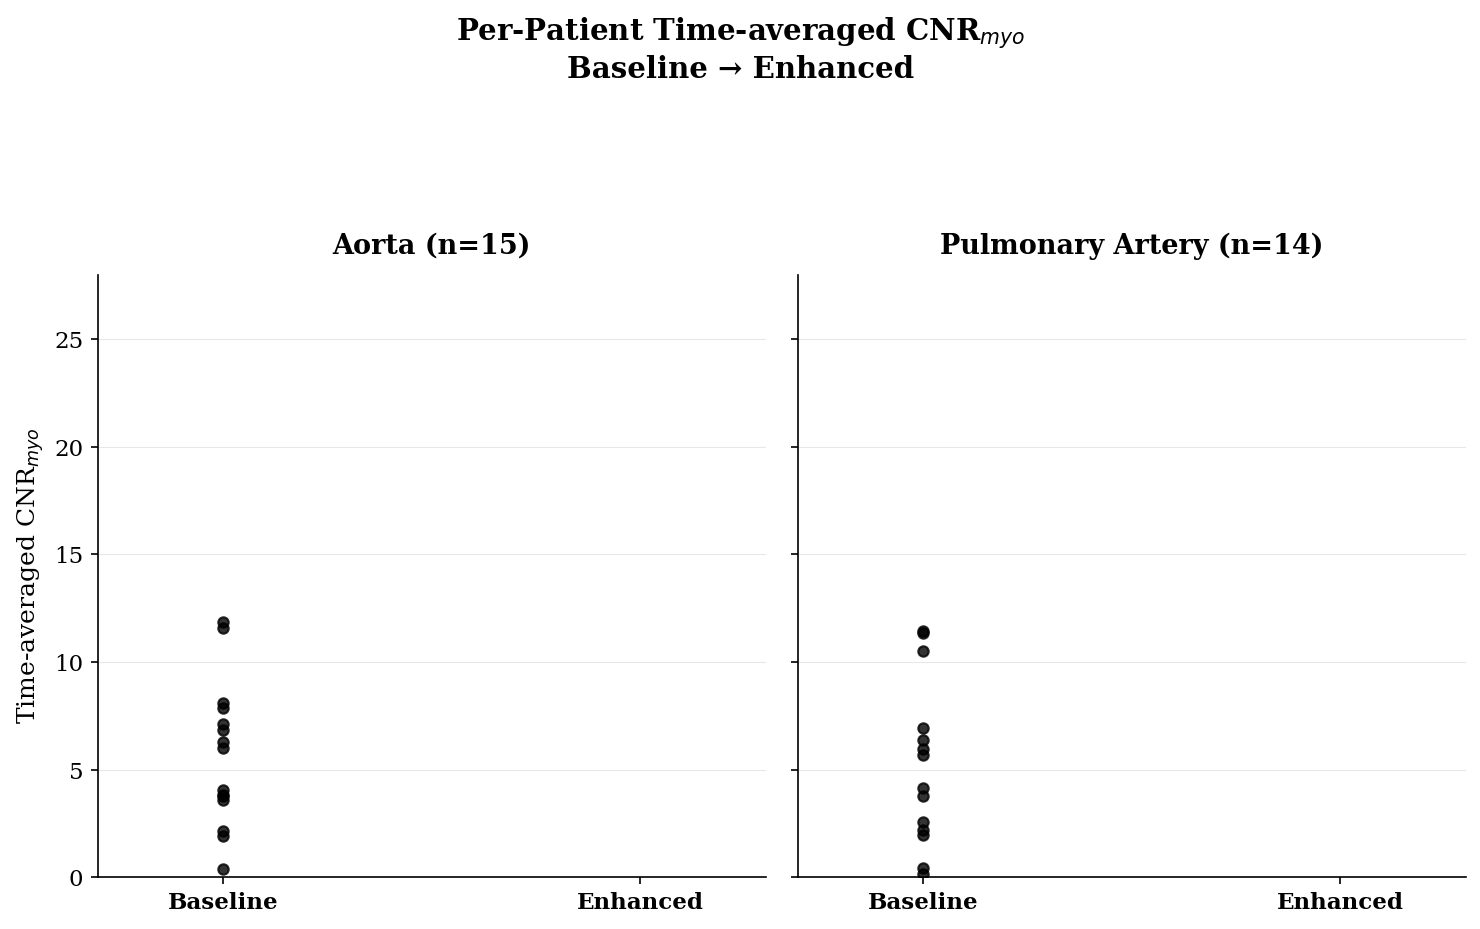

Saved: fig2_cnr_myo_paired_baseline.png


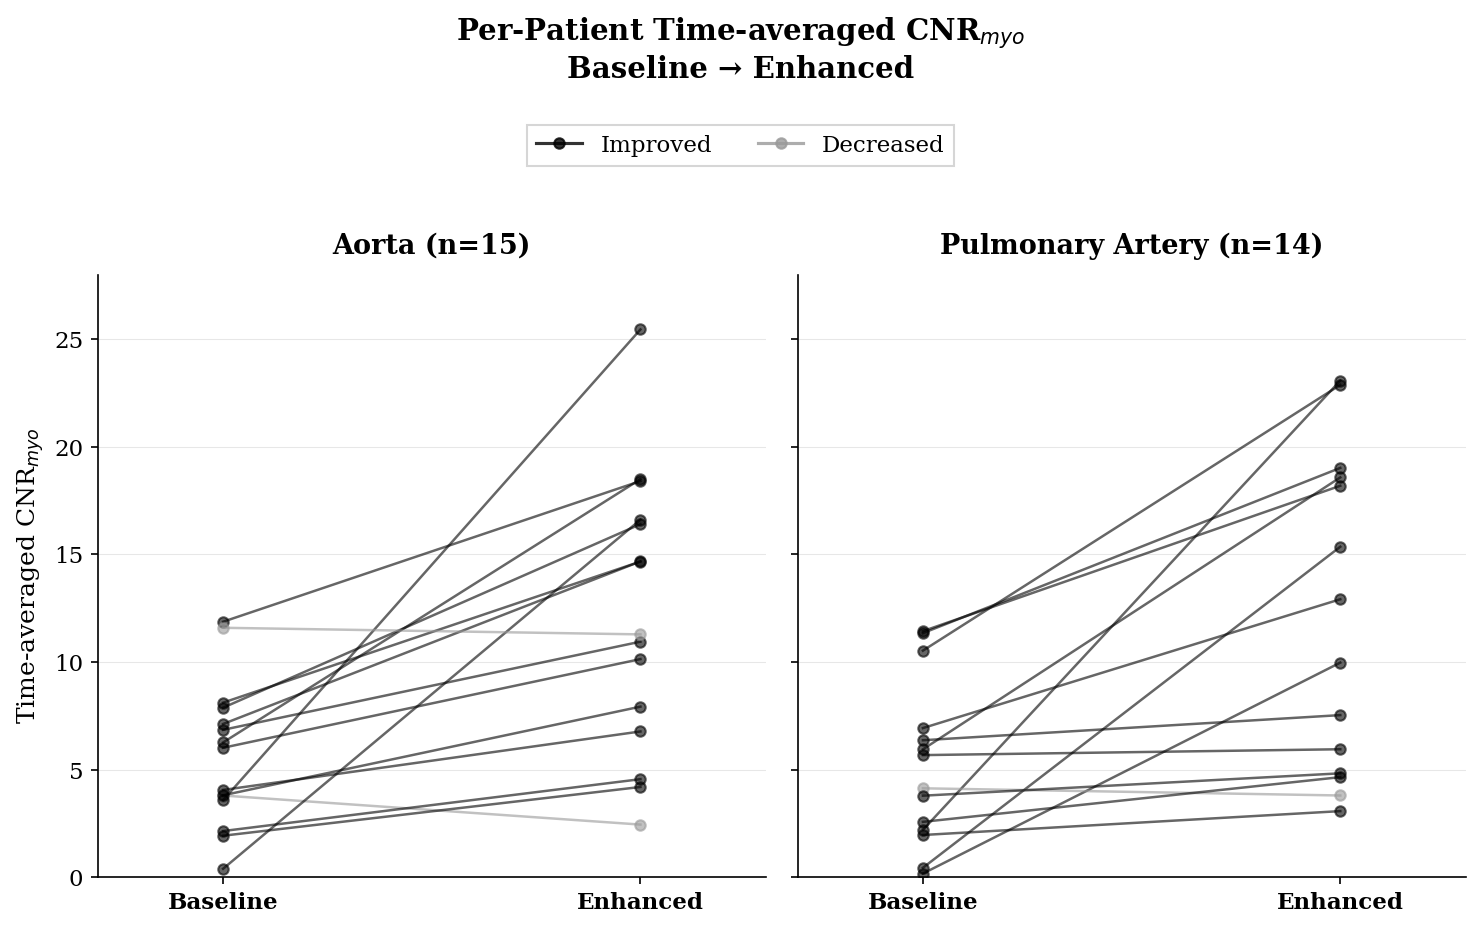

Saved: fig2_cnr_myo_paired_full.png


In [4]:
SLOPE_UP = "black"
SLOPE_DOWN = "#999999"

def _paired_slope(pivot_df, region_list, ylabel, fig_basename,
                  figsize_per_panel=(5, 5.5)):
    """Publication-ready paired slope graph with build-up stages."""

    # Precompute consistent y-limits across both baseline and enhanced values
    pdf_all = pivot_df.reset_index().dropna(subset=["normal", "vse"])
    all_vals = pd.concat([pdf_all["normal"], pdf_all["vse"]])
    ylim = (min(0, all_vals.min() * 0.95), all_vals.max() * 1.10)

    STAGES = [
        ("baseline", False),
        ("full",     True),
    ]

    for stage_name, show_enhanced in STAGES:
        fig, axes = plt.subplots(
            1, len(region_list),
            figsize=(figsize_per_panel[0] * len(region_list), figsize_per_panel[1]),
            sharey=True,
        )
        if len(region_list) == 1:
            axes = [axes]

        for ax, region in zip(axes, region_list):
            pdf = pivot_df.reset_index()
            sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])

            if show_enhanced:
                for _, row in sub.iterrows():
                    color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
                    ax.plot([0, 1], [row["normal"], row["vse"]],
                            marker="o", color=color, alpha=0.6,
                            linewidth=1.2, markersize=5)
            else:
                ax.plot(np.zeros(len(sub)), sub["normal"].values,
                        "o", color="black", alpha=0.8, markersize=5)

            ax.set_xticks([0, 1])
            ax.set_xticklabels([LABELS["normal"], LABELS["vse"]], fontweight="bold")
            n_region = len(sub)
            ax.set_title(f"{REGION_LABELS[region]} (n={n_region})", fontweight="bold", pad=10)
            ax.set_xlim(-0.3, 1.3)
            ax.set_ylim(ylim)

        axes[0].set_ylabel(ylabel)

        if show_enhanced:
            legend_handles = [
                plt.Line2D([], [], color="black", marker="o",
                           markersize=5, alpha=0.8, label="Improved"),
                plt.Line2D([], [], color="#999999", marker="o",
                           markersize=5, alpha=0.8, label="Decreased"),
            ]
            fig.legend(handles=legend_handles, loc="upper center", ncol=2,
                       frameon=True, fancybox=False, edgecolor="#ccc",
                       fontsize=11, bbox_to_anchor=(0.5, 1.0))

        fig.suptitle(f"Per-Patient {ylabel}\nBaseline → Enhanced",
                     fontsize=14, fontweight="bold", y=1.12)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"{fig_basename}_{stage_name}.png",
                    bbox_inches="tight", dpi=300, facecolor="white")
        plt.show()
        print(f"Saved: {fig_basename}_{stage_name}.png")

_paired_slope(cnr_myo_pivot, cnr_regions,
              "Time-averaged CNR$_{myo}$", "fig2_cnr_myo_paired")

## Figure 3: Per-Patient Signal Intensity — Baseline → Enhanced

Same paired slope format, now showing raw mean SI across all four ROI regions
(Ao, Air, IVS, PA). Verifies that VSE boosts vessel signal while
air stays flat.

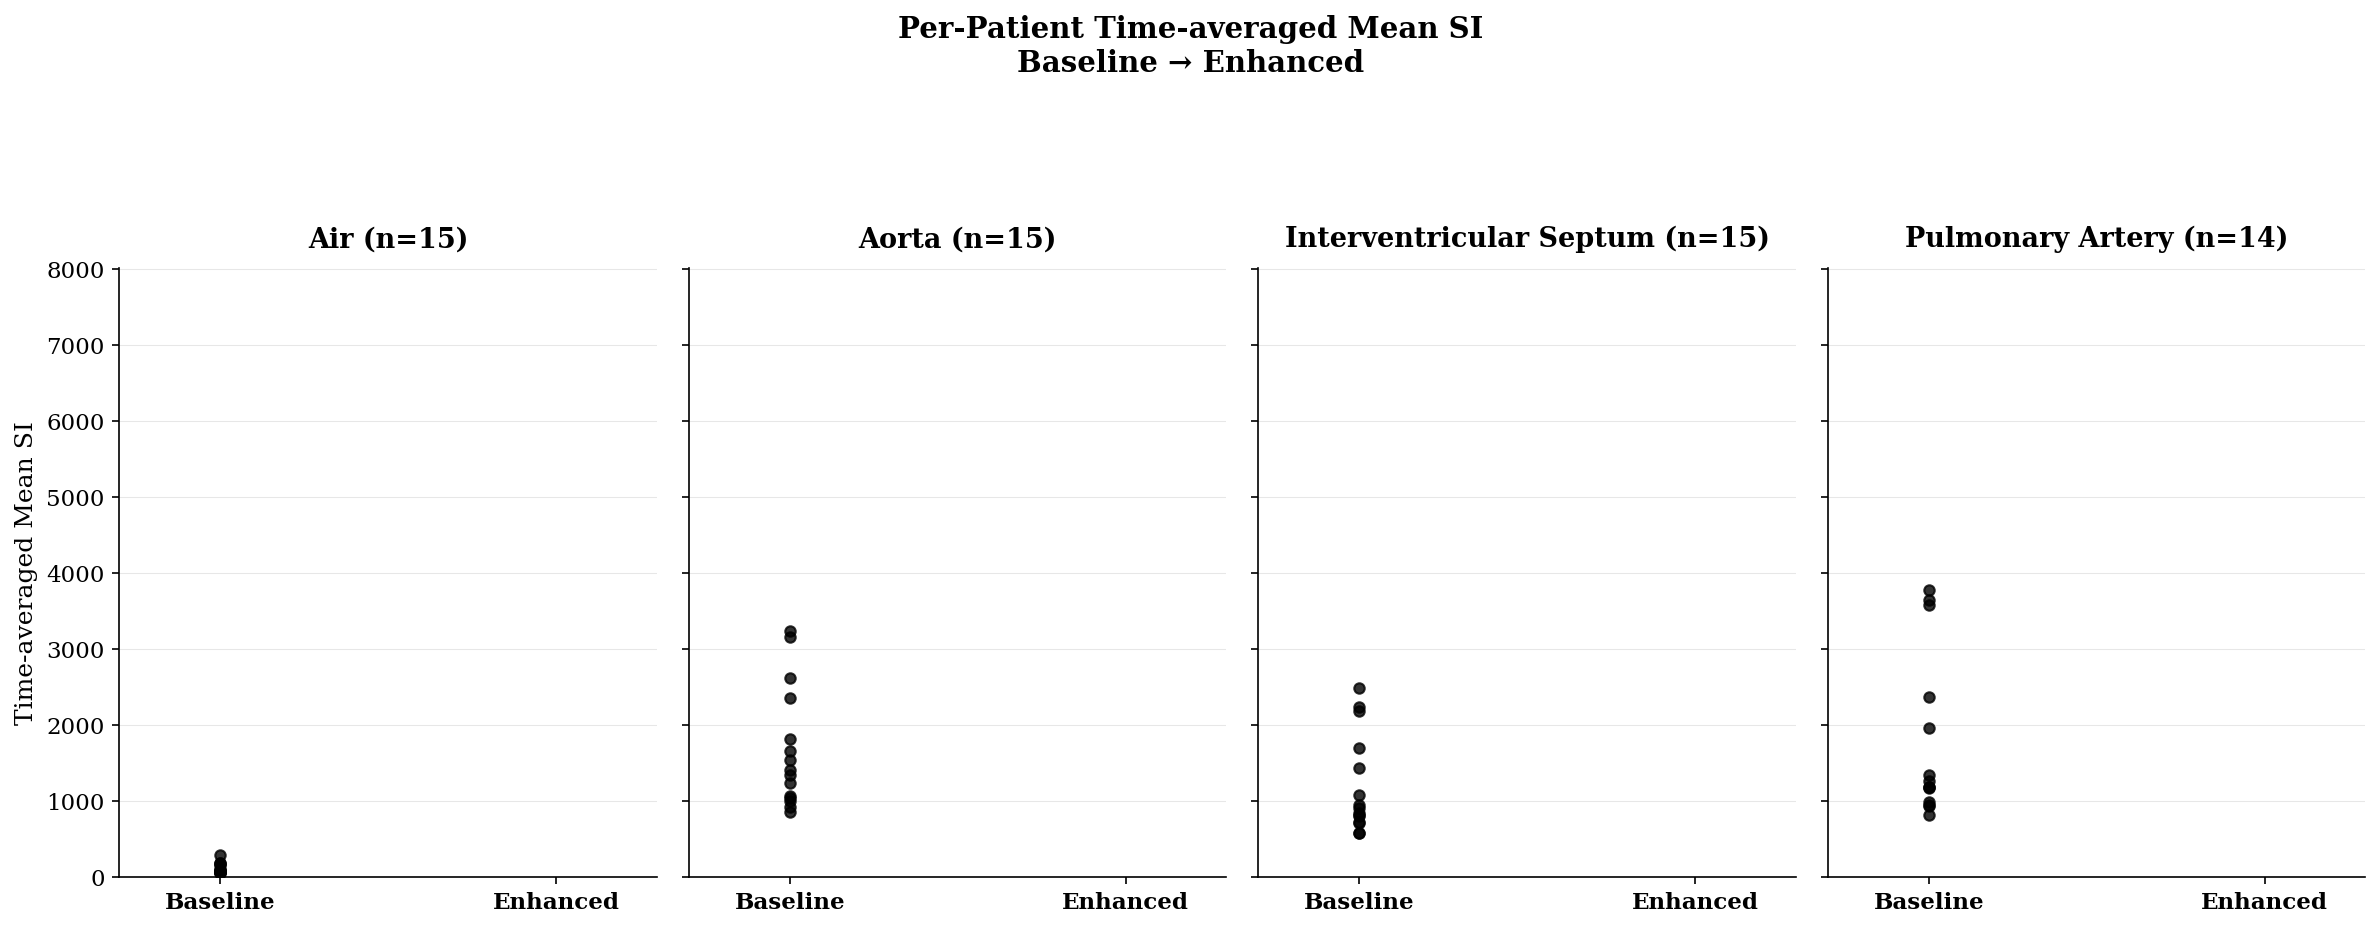

Saved: fig3_si_paired_baseline.png


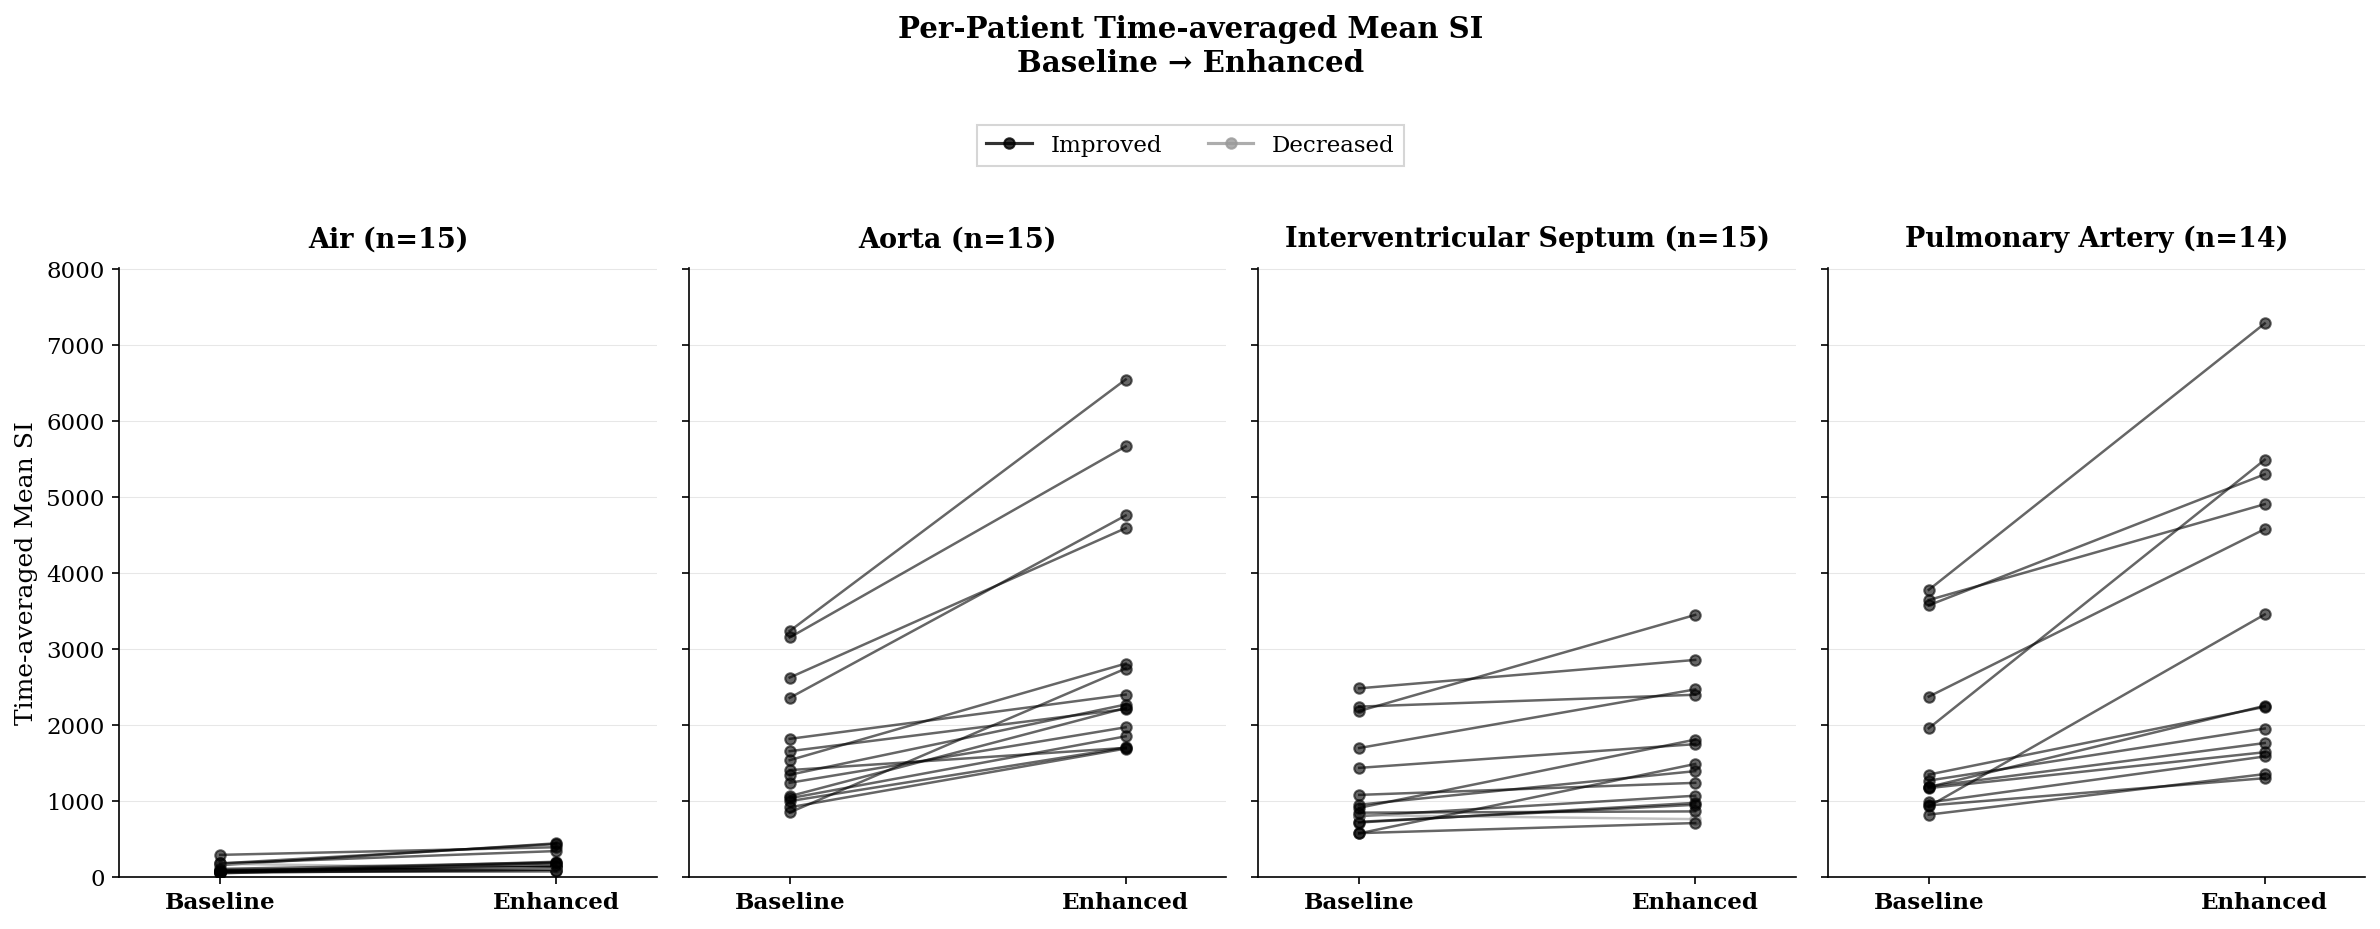

Saved: fig3_si_paired_full.png


In [5]:
_paired_slope(si_pivot, regions,
              "Time-averaged Mean SI", "fig3_si_paired",
              figsize_per_panel=(4, 5.5))